**RESNET50 MODEL**



In [13]:
from google.colab import drive
import os

# Mount Drive
drive.mount('/content/drive')

# Extract RAR file
!apt-get install -y unrar  # Install unrar tool

# Extract from Drive to /content/
!unrar x /content/drive/MyDrive/ResNet_Project/project.rar /content/

# Verify structure
!ls -la /content/project/

print("✓ Files extracted!")

Mounted at /content/drive
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/ResNet_Project/project.rar

Creating    /content/project/.vscode                                  OK
Extracting  /content/project/.vscode/settings.json                         0%  OK 
Creating    /content/project/data                                     OK
Creating    /content/project/data/processed                           OK
Extracting  /content/project/data/processed/test_labels.csv                0%  OK 
Extracting  /content/project/data/processed/train_labels.csv               0%  OK 
Extracting  /content/project/data/processed/val_labels.csv                 0%  OK 
Creating    /content/proj

In [14]:
!ls /content/project/project/data

processed  raw	test  train  val


In [17]:
import os
from pathlib import Path

# Check complete structure
base = Path("/content/project/project/data")

print("=== Current Structure ===")
for root, dirs, files in os.walk(base):
    level = root.replace(str(base), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')

    # Only show first 3 files per directory
    subindent = ' ' * 2 * (level + 1)
    for i, file in enumerate(files[:3]):
        print(f'{subindent}{file}')
    if len(files) > 3:
        print(f'{subindent}... and {len(files)-3} more files')

    # Stop after showing 2 levels deep
    if level >= 2:
        break

# Count actual images
print("\n=== Image Count ===")
for split in ['train', 'val', 'test']:
    # Check in data/split/
    path1 = base / split
    if path1.exists():
        imgs1 = list(path1.glob("**/*.jpg")) + list(path1.glob("**/*.png"))
        print(f"data/{split}/: {len(imgs1)} images")
        if imgs1:
            print(f"  Example: {imgs1[0]}")

    # Check in data/processed/split/
    path2 = base / "processed" / split
    if path2.exists():
        imgs2 = list(path2.glob("**/*.jpg")) + list(path2.glob("**/*.png"))
        print(f"data/processed/{split}/: {len(imgs2)} images")
        if imgs2:
            print(f"  Example: {imgs2[0]}")

# Check CSV paths
print("\n=== CSV Paths ===")
csv_path = base / "processed" / "train_labels.csv"
if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"CSV row 0: {df['image_path'].iloc[0]}")
    print(f"CSV row 1: {df['image_path'].iloc[1]}")
    print(f"CSV row 2: {df['image_path'].iloc[2]}")

    # Check if any path exists
    print("\nChecking if paths exist:")
    for i in range(min(5, len(df))):
        path = df['image_path'].iloc[i]
        exists = os.path.exists(path)
        print(f"  Row {i}: {exists} - {Path(path).name}")

=== Current Structure ===
data/
  val/
    0039/
      0039_2m_-30P_10V_0H.jpg
      0039_2m_30P_10V_-15H.jpg
      0039_2m_-30P_0V_15H.jpg
      ... and 102 more files

=== Image Count ===
data/train/: 3420 images
  Example: /content/project/project/data/train/0029/0029_2m_0P_0V_10H.jpg
data/val/: 630 images
  Example: /content/project/project/data/val/0039/0039_2m_-30P_10V_0H.jpg
data/test/: 750 images
  Example: /content/project/project/data/test/0009/0009_2m_-30P_10V_0H.jpg

=== CSV Paths ===
CSV row 0: D:\FAST hamdan\7th Semester\DS\project\data\train\0001\0001_2m_-15P_-10V_-10H.jpg
CSV row 1: D:\FAST hamdan\7th Semester\DS\project\data\train\0001\0001_2m_-15P_-10V_-15H.jpg
CSV row 2: D:\FAST hamdan\7th Semester\DS\project\data\train\0001\0001_2m_-15P_-10V_-5H.jpg

Checking if paths exist:
  Row 0: False - D:\FAST hamdan\7th Semester\DS\project\data\train\0001\0001_2m_-15P_-10V_-10H.jpg
  Row 1: False - D:\FAST hamdan\7th Semester\DS\project\data\train\0001\0001_2m_-15P_-10V_-15H.


=== Fixing train_labels.csv ===
Valid after rebuild: 0/3420
After filtering: 0 images remain
✓ Saved /content/project/data/processed/train_labels.csv

=== Fixing val_labels.csv ===
Valid after rebuild: 0/630
After filtering: 0 images remain
✓ Saved /content/project/data/processed/val_labels.csv

=== Fixing test_labels.csv ===
Valid after rebuild: 0/750
After filtering: 0 images remain
✓ Saved /content/project/data/processed/test_labels.csv


In [27]:
!ls -R /content/project


/content/project:
data  project  Resnet50_train.py

/content/project/data:
processed  raw	test  train  val

/content/project/data/processed:
test_labels.csv  train_labels.csv  val_labels.csv

/content/project/data/raw:

/content/project/data/test:
0002  0007  0008  0009	0015  0016  0018  0045

/content/project/data/test/0002:
0002_2m_0P_0V_0H.jpg	    0002_2m_15P_10V_-15H.jpg
0002_2m_0P_0V_-10H.jpg	    0002_2m_15P_10V_15H.jpg
0002_2m_0P_0V_10H.jpg	    0002_2m_-15P_-10V_-5H.jpg
0002_2m_0P_0V_-15H.jpg	    0002_2m_-15P_-10V_5H.jpg
0002_2m_0P_0V_15H.jpg	    0002_2m_-15P_10V_-5H.jpg
0002_2m_0P_0V_-5H.jpg	    0002_2m_-15P_10V_5H.jpg
0002_2m_0P_0V_5H.jpg	    0002_2m_15P_-10V_-5H.jpg
0002_2m_0P_-10V_0H.jpg	    0002_2m_15P_-10V_5H.jpg
0002_2m_0P_10V_0H.jpg	    0002_2m_15P_10V_-5H.jpg
0002_2m_0P_-10V_-10H.jpg    0002_2m_15P_10V_5H.jpg
0002_2m_0P_-10V_10H.jpg     0002_2m_-30P_0V_0H.jpg
0002_2m_0P_10V_-10H.jpg     0002_2m_30P_0V_0H.jpg
0002_2m_0P_10V_10H.jpg	    0002_2m_-30P_0V_-10H.jpg
0002_2m_0P_

In [30]:
import pandas as pd
from pathlib import Path

base = Path("/content/project/data")

def parse_filename(fname):
    """
    Extract labels from filename like:
    0001_2m_0P_-10V_-10H.jpg
    """
    parts = fname.split("_")

    pid = parts[0]          # 0001
    dist = parts[1]         # 2m
    P = parts[2].replace("P", "")
    V = parts[3].replace("V", "")
    H = parts[4].replace("H", "").split(".")[0]

    return pid, dist, int(P), int(V), int(H)


for split in ["train", "val", "test"]:
    print(f"\nProcessing {split}...")

    rows = []

    split_dir = base / split
    for folder in split_dir.iterdir():
        if folder.is_dir():     # 0001, 0004, 0007 etc
            for img in folder.glob("*.jpg"):

                pid, dist, P, V, H = parse_filename(img.name)

                rows.append({
                    "image_path": str(img),
                    "pid": pid,
                    "distance": dist,
                    "pitch": P,
                    "vert": V,
                    "horiz": H
                })

    df = pd.DataFrame(rows)
    df.to_csv(base / "processed" / f"{split}_labels.csv", index=False)

    print(f"Saved {len(df)} rows → {split}_labels.csv")



Processing train...
Saved 3420 rows → train_labels.csv

Processing val...
Saved 630 rows → val_labels.csv

Processing test...
Saved 750 rows → test_labels.csv


In [31]:
import pandas as pd

train = pd.read_csv("/content/project/data/processed/train_labels.csv")
val = pd.read_csv("/content/project/data/processed/val_labels.csv")
test = pd.read_csv("/content/project/data/processed/test_labels.csv")

print("TRAIN:", len(train))
print("VAL:", len(val))
print("TEST:", len(test))

print(train.head())


TRAIN: 3420
VAL: 630
TEST: 750
                                          image_path  pid distance  pitch  \
0  /content/project/data/train/0029/0029_2m_0P_0V...   29       2m      0   
1  /content/project/data/train/0029/0029_2m_-15P_...   29       2m    -15   
2  /content/project/data/train/0029/0029_2m_15P_0...   29       2m     15   
3  /content/project/data/train/0029/0029_2m_0P_0V...   29       2m      0   
4  /content/project/data/train/0029/0029_2m_-15P_...   29       2m    -15   

   vert  horiz  
0     0     10  
1    10     15  
2     0      5  
3     0      0  
4     0    -15  


In [32]:
!python /content/project/Resnet50_train.py \
  --processed_dir /content/project/data/processed \
  --output_dir /content/drive/MyDrive/ResNet_Project/outputs_resnet50 \
  --image_size 224 \
  --batch_size 32 \
  --epochs 25 \
  --freeze_epochs 5 \
  --lr 1e-4 \
  --seed 42 \
  --num_workers 2


Dataset sizes - train: 3420, val: 630, test: 750
Class weights (train): [2.3217924  0.7307692  0.83272463]
Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100% 97.8M/97.8M [00:00<00:00, 164MB/s]
Backbone frozen. Training head for 5 epochs.

=== Epoch 1/25 ===
Train Loss: 1.0431  |  Train Acc: 0.4877
Val   Loss: 0.9659  |  Val   Acc: 0.4683
Saved best model -> /content/drive/MyDrive/ResNet_Project/outputs_resnet50/best_resnet50.pth (val_acc=0.4683)

=== Epoch 2/25 ===
Train Loss: 0.9270  |  Train Acc: 0.6246
Val   Loss: 0.8620  |  Val   Acc: 0.6968
Saved best model -> /content/drive/MyDrive/ResNet_Project/outputs_resnet50/best_resnet50.pth (val_acc=0.6968)

=== Epoch 3/25 ===
Train Loss: 0.8467  |  Train Acc: 0.6754
Val   Loss: 0.7870  |  Val   Acc: 0.6794

=== Epoch 4/25 ===
Train Loss: 0.7786  |  Train Acc: 0.7237
Val   Loss: 0.7419  |  Val   Acc: 0.5937

=== Epoch 5/25 ===
Train Lo

In [37]:
!find /content/project -name "best_resnet50.pth"


In [38]:
from google.colab import files

# Download from Drive
files.download('/content/drive/MyDrive/ResNet_Project/outputs_resnet50/best_resnet50.pth')
files.download('/content/drive/MyDrive/ResNet_Project/outputs_resnet50/test_report.json')
files.download('/content/drive/MyDrive/ResNet_Project/outputs_resnet50/classification_report.txt')
files.download('/content/drive/MyDrive/ResNet_Project/outputs_resnet50/train_history.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

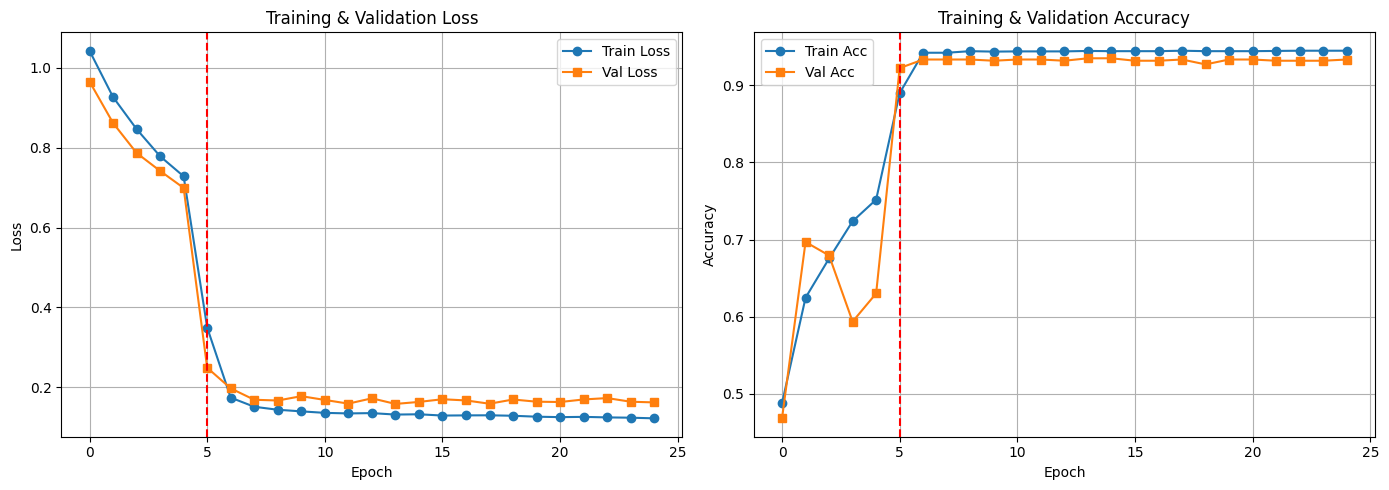

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

hist = pd.read_csv('/content/drive/MyDrive/ResNet_Project/outputs_resnet50/train_history.csv')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Loss
ax1.plot(hist['train_loss'], label='Train Loss', marker='o')
ax1.plot(hist['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True)
ax1.axvline(x=5, color='red', linestyle='--')

# Accuracy
ax2.plot(hist['train_acc'], label='Train Acc', marker='o')
ax2.plot(hist['val_acc'], label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()
ax2.grid(True)
ax2.axvline(x=5, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ResNet_Project/outputs_resnet50/training_curves.png', dpi=150)
plt.show()


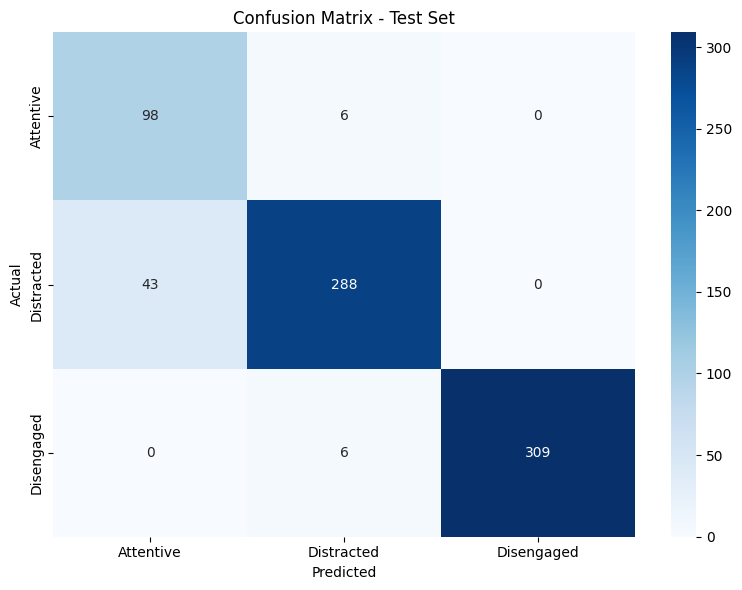

In [40]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

cm = np.array([[98, 6, 0],
               [43, 288, 0],
               [0, 6, 309]])

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attentive','Distracted','Disengaged'],
            yticklabels=['Attentive','Distracted','Disengaged'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ResNet_Project/outputs_resnet50/confusion_matrix.png', dpi=150)
plt.show()


In [47]:
import torch
from PIL import Image
from torchvision import transforms
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

checkpoint = torch.load('/content/drive/MyDrive/ResNet_Project/outputs_resnet50/best_resnet50.pth',
                        map_location=device)

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 3)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def predict_image(image_path):
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred = torch.argmax(probs).item()

    classes = ['Attentive','Distracted','Disengaged']

    print(f"\nPrediction: {classes[pred]}")
    print("Confidence Scores:")
    for i, cls in enumerate(classes):
        print(f"  {cls}: {probs[i]*100:.2f}%")

    return pred, probs

# Test Example
sample_img = '/content/project/data/test/0016/0016_2m_-30P_-10V_-15H.jpg'
predict_image(sample_img)



Prediction: Disengaged
Confidence Scores:
  Attentive: 0.01%
  Distracted: 0.03%
  Disengaged: 99.96%


(2, tensor([9.8406e-05, 2.5875e-04, 9.9964e-01], device='cuda:0'))